In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))

import subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "-r", "../../requirements.txt", "-q"])

import numpy as np
print(sys.executable)
print(np.__version__)

from made import manifolds, visuals
from made.can import CAN

/Users/jacobhornsvennevik/anaconda3/bin/python
1.26.4


## Manifold

Create a Manifold and visualize the distance metric over it. 

Torus(dim=2, parameter_space=ParameterSpace(ranges=[Range(start=0, end=6.283185307179586, periodic=True), Range(start=0, end=6.283185307179586, periodic=True)]), metric=<made.metrics.PeriodicEuclidean object at 0x1186e5910>)
<class 'made.manifolds.Torus'>


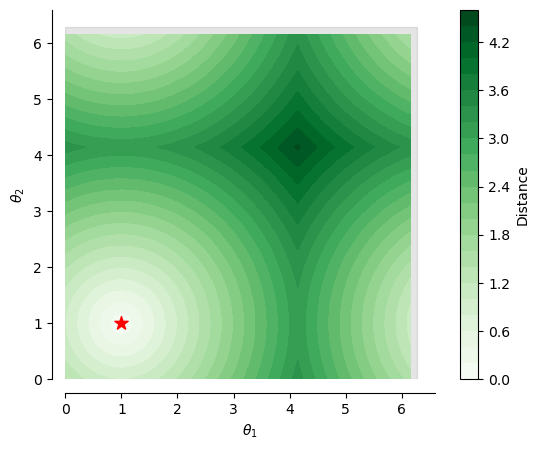

In [2]:
m = manifolds.Torus()


print(m)
print(type(m))

# define a sample point
if not isinstance(m, manifolds.Sphere):
    # manually set coordinates
    
    sample = np.array([1, 1])
else:
    # pick one neuron from the sphere
    idx = np.random.randint(0, 99)
    sample = m.parameter_space.sample(100)[idx, :]

assert m.contains(sample), "Sample point is not in the manifold"

f, ax = visuals.visualize_manifold(m, show_distances=True, distance_point=sample)


## CAN
Create a CAN and visualize the connnectivity matrix from a few sampled neurons. 

In [ ]:
can = CAN.default(topology='MobiusBand')
print(can)
visuals.visualize_can_connectivity(can, );

## Plot a CAN state
We can simulate the CAN dynamics and visualize the bump over the lattice.

In [ ]:
if isinstance(can.manifold, manifolds.Sphere):
    idx = np.random.randint(0, 99)
    sample_coords = can.manifold.parameter_space.sample(100)[idx, :]
else:
    sample_coords = [-2, 0]
assert can.manifold.contains(sample_coords), "Sample coordinates not in manifold"

can.reset(mode="point", point=np.array(sample_coords))
for i in range(50):
    can()

visuals.visualize_can_state(can);